In [18]:
import pandas as pd
from economic_data_fetcher import EconomicDataFetcher

In [21]:
# Initialize the fetcher
fetcher = EconomicDataFetcher(raw_data_dir='raw_data', cache_dir='data')


all_data = fetcher.process_all_data()

# Get summary of cached datasets
summary = fetcher.get_summary()
print(summary)

📊 PROCESSING ALL INDIAN ECONOMIC DATA


Processing: GDP
🔍 Loading GDP data...
✅ Processed GDP data: 53 records
📅 Date range: 2012-04 to 2025-04
💾 Cached: gdp_data.csv

Processing: Inflation
🔍 Loading inflation data...
✅ Processed inflation data: 235 records
📅 Date range: 2006-04 to 2025-10
💾 Cached: inflation_data.csv

Processing: Foreign Trade
🔍 Loading foreign trade data...
✅ Processed trade data: 425 records
📅 Date range: 1990-04 to 2025-08
💾 Cached: trade_data.csv

Processing: Forex Reserves
🔍 Loading forex reserves data...
✅ Processed forex reserves: 136 records
📅 Date range: 2023-04-07 to 2025-11-07
💾 Cached: forex_reserves.csv

Processing: Exchange Rates
🔍 Loading exchange rate data...
✅ Processed exchange rates: 6583 records
📅 Date range: 1998-08-25 to 2025-11-13
💾 Cached: exchange_rate.csv

Processing: RBI Rates
🔍 Loading RBI rates data...
✅ Processed RBI rates: 257 records
📅 Date range: 1935-07-05 to 2025-11-01
💾 Cached: rbi_rates.csv

Processing: IIP
🔍 Loading IIP data from 

In [22]:
print(gdp[['date', 'GDP', 'gdp_growth_yoy', 'investment_rate']].tail())

         date       GDP  gdp_growth_yoy  investment_rate
48 2024-04-01  6.511800      -32.589675       102.124275
49 2024-07-01  5.612025      -39.932631       119.438204
50 2024-10-01  6.366486      -33.086879        82.153877
51 2025-01-01  7.384530      -11.611633       127.391783
52 2025-04-01  7.811474       19.958753       100.099873


🔍 Loading inflation data...
✅ Processed inflation data: 235 records
📅 Date range: 2006-04 to 2025-10
💾 Cached: inflation_data.csv


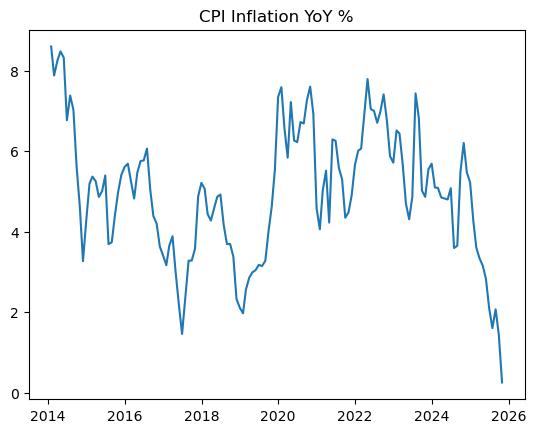

In [24]:
inflation = fetcher.load_inflation_data()
import matplotlib.pyplot as plt
plt.plot(inflation['date'], inflation['CPI_inflation_yoy'])
plt.title('CPI Inflation YoY %')
plt.show()

In [25]:
trade = fetcher.load_trade_data()
trade_deficit = trade['trade_balance_rupees'].mean()
print(f"Average trade deficit: ₹{trade_deficit:,.0f} crores")

🔍 Loading foreign trade data...
✅ Processed trade data: 425 records
📅 Date range: 1990-04 to 2025-08
💾 Cached: trade_data.csv
Average trade deficit: ₹-49,756 crores


In [26]:
forex = fetcher.load_forex_reserves_data()

print(f"Latest reserves: ${forex['total_reserves_usd'].iloc[-1]:,.0f} million")


🔍 Loading forex reserves data...
✅ Processed forex reserves: 136 records
📅 Date range: 2023-04-07 to 2025-11-07
💾 Cached: forex_reserves.csv
Latest reserves: $687,034 million


In [27]:
exchange = fetcher.load_exchange_rate_data()
latest_rate = exchange['USD_INR'].iloc[-1]
year_ago_rate = exchange['USD_INR'].iloc[-252]
depreciation = ((latest_rate - year_ago_rate) / year_ago_rate) * 100
print(f"Rupee depreciation: {depreciation:.2f}%")


🔍 Loading exchange rate data...
✅ Processed exchange rates: 6583 records
📅 Date range: 1998-08-25 to 2025-11-13
💾 Cached: exchange_rate.csv
Rupee depreciation: 5.52%


In [29]:
merged = pd.merge(
    gdp[['date', 'GDP', 'gdp_growth_yoy']],
    inflation[['date', 'CPI_inflation_yoy']],
    on='date',
    how='inner'
)

correlation = merged['gdp_growth_yoy'].corr(merged['CPI_inflation_yoy'])
print(f"GDP Growth vs Inflation correlation: {correlation:.3f}")

GDP Growth vs Inflation correlation: nan


In [30]:
summary = fetcher.get_summary()
print(summary)

           Dataset  Records  Columns  Size (KB)
0    exchange_rate     6583       10     877.79
1   forex_reserves      136       15      23.47
2         gdp_data       53       19      16.27
3   inflation_data      235       16      29.09
4  payment_systems       70      142     101.52
5        rbi_rates      257        8       8.76
6       trade_data      425       25      90.67


In [31]:
iip_growth = fetcher.load_iip_data(sheet_name='IIP Growth Rate')

🔍 Loading IIP data from sheet: IIP Growth Rate...
❌ Error loading IIP data: arg must be a list, tuple, 1-d array, or Series


In [33]:
iip_industry = fetcher.load_iip_data(sheet_name='IIP-Industry-Base(2011-12)')

🔍 Loading IIP data from sheet: IIP-Industry-Base(2011-12)...
❌ Error loading IIP data: arg must be a list, tuple, 1-d array, or Series


🔍 Loading GDP data...
✅ Processed GDP data: 53 records
📅 Date range: 2012-04 to 2025-04
💾 Cached: gdp_data.csv
🔍 Loading inflation data...
✅ Processed inflation data: 235 records
📅 Date range: 2006-04 to 2025-10
💾 Cached: inflation_data.csv


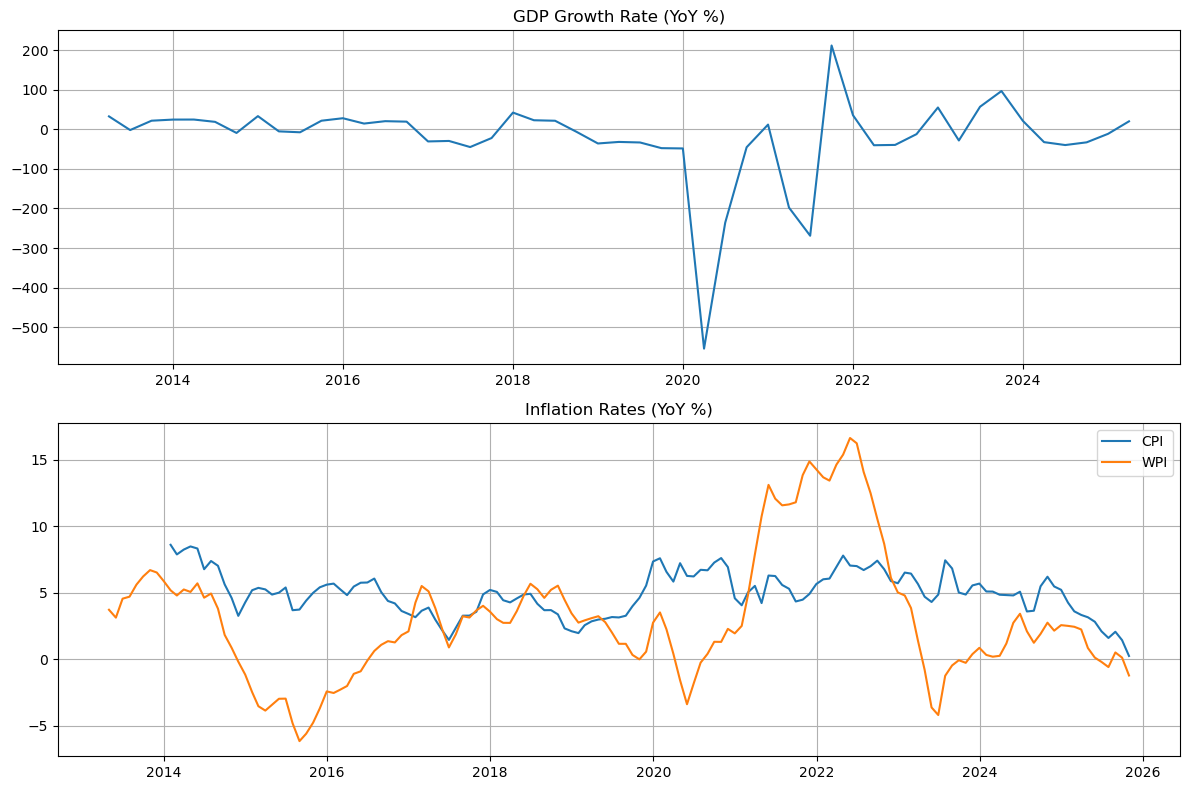

In [34]:
from economic_data_fetcher import EconomicDataFetcher
import pandas as pd
import matplotlib.pyplot as plt

# Initialize
fetcher = EconomicDataFetcher(raw_data_dir='raw_data', cache_dir='data')

# Load data
gdp = fetcher.load_gdp_data()
inflation = fetcher.load_inflation_data()

# Create visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# GDP Growth
ax1.plot(gdp['date'], gdp['gdp_growth_yoy'])
ax1.set_title('GDP Growth Rate (YoY %)')
ax1.grid(True)

# Inflation
ax2.plot(inflation['date'], inflation['CPI_inflation_yoy'], label='CPI')
ax2.plot(inflation['date'], inflation['WPI_inflation_yoy'], label='WPI')
ax2.set_title('Inflation Rates (YoY %)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [35]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd

# Color palette
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'success': '#2ca02c',
    'danger': '#d62728',
    'warning': '#ff7f0e',
    'info': '#17becf',
    'neutral': '#7f7f7f'
}

def create_gdp_trend_chart(df):
    """GDP absolute value trend with YoY growth overlay"""
    
    # Create figure with secondary y-axis
    fig = make_subplots(
        specs=[[{"secondary_y": True}]]
    )
    
    # GDP absolute values (bar chart)
    fig.add_trace(
        go.Bar(
            x=df['date'],
            y=df['GDP'],
            name='GDP (₹ Lakh Cr)',
            marker_color=COLORS['primary'],
            opacity=0.7,
            hovertemplate='<b>%{x|%Y %b}</b><br>GDP: ₹%{y:,.2f} L Cr<extra></extra>'
        ),
        secondary_y=False
    )
    
    # YoY Growth rate (line chart)
    fig.add_trace(
        go.Scatter(
            x=df['date'],
            y=df['gdp_growth_yoy'],
            name='YoY Growth (%)',
            mode='lines+markers',
            line=dict(color=COLORS['success'], width=3),
            marker=dict(size=6),
            hovertemplate='<b>%{x|%Y %b}</b><br>Growth: %{y:.2f}%<extra></extra>'
        ),
        secondary_y=True
    )
    
    # Add zero line for growth rate
    fig.add_hline(y=0, line_dash="dash", line_color="gray", 
                  opacity=0.5, secondary_y=True)
    
    fig.update_xaxes(title_text="")
    fig.update_yaxes(title_text="GDP (₹ Lakh Crores)", secondary_y=False)
    fig.update_yaxes(title_text="YoY Growth (%)", secondary_y=True)
    
    fig.update_layout(
        title='India GDP: Absolute Value & Growth Rate',
        hovermode='x unified',
        template='plotly_white',
        height=500,
        font=dict(family='Arial', size=12),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )
    
    return fig

def create_gdp_components_stacked(df):
    """Stacked area chart of GDP components"""
    
    fig = go.Figure()
    
    components = {
        'PFCE': 'Private Consumption',
        'GFCE': 'Govt Consumption',
        'GFCF': 'Investment',
        'exports': 'Exports',
        'change_in_stock': 'Stock Change',
        'valuables': 'Valuables'
    }
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i, (col, label) in enumerate(components.items()):
        if col in df.columns:
            fig.add_trace(go.Scatter(
                x=df['date'],
                y=df[col],
                name=label,
                mode='lines',
                stackgroup='one',
                fillcolor=colors[i],
                line=dict(width=0.5, color=colors[i]),
                hovertemplate=f'<b>{label}</b><br>%{{y:,.2f}} L Cr<extra></extra>'
            ))
    
    # Imports as negative (subtract from stack)
    fig.add_trace(go.Scatter(
        x=df['date'],
        y=-df['imports'],
        name='Imports (negative)',
        mode='lines',
        stackgroup='one',
        fillcolor='lightgray',
        line=dict(width=0.5, color='gray'),
        hovertemplate='<b>Imports</b><br>%{y:,.2f} L Cr<extra></extra>'
    ))
    
    fig.update_layout(
        title='GDP Components Over Time (Stacked)',
        xaxis_title='',
        yaxis_title='₹ Lakh Crores',
        hovermode='x unified',
        template='plotly_white',
        height=500
    )
    
    return fig

def create_gdp_components_percent(df):
    """GDP components as percentage of total"""
    
    # Calculate percentages
    df_pct = df.copy()
    components = ['PFCE', 'GFCE', 'GFCF', 'exports']
    
    for col in components:
        df_pct[f'{col}_pct'] = (df[col] / df['GDP']) * 100
    
    fig = go.Figure()
    
    component_labels = {
        'PFCE_pct': 'Private Consumption',
        'GFCE_pct': 'Govt Consumption',
        'GFCF_pct': 'Investment',
        'exports_pct': 'Exports'
    }
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, (col, label) in enumerate(component_labels.items()):
        fig.add_trace(go.Scatter(
            x=df_pct['date'],
            y=df_pct[col],
            name=label,
            mode='lines',
            line=dict(width=2, color=colors[i]),
            hovertemplate=f'<b>{label}</b><br>%{{y:.1f}}% of GDP<extra></extra>'
        ))
    
    fig.update_layout(
        title='GDP Components as % of Total GDP',
        xaxis_title='',
        yaxis_title='% of GDP',
        hovermode='x unified',
        template='plotly_white',
        height=450
    )
    
    return fig

def create_trade_balance_chart(df):
    """Trade balance (exports - imports)"""
    
    fig = go.Figure()
    
    # Net exports
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in df['net_exports']]
    
    fig.add_trace(go.Bar(
        x=df['date'],
        y=df['net_exports'],
        name='Net Exports',
        marker=dict(color=colors),
        hovertemplate='<b>%{x|%Y %b}</b><br>Net Exports: ₹%{y:,.2f} L Cr<extra></extra>'
    ))
    
    fig.add_hline(y=0, line_dash="solid", line_color="black", line_width=1)
    
    fig.update_layout(
        title='Trade Balance (Exports - Imports)',
        xaxis_title='',
        yaxis_title='₹ Lakh Crores',
        hovermode='x',
        template='plotly_white',
        height=400,
        annotations=[
            dict(
                text="Surplus" if df['net_exports'].iloc[-1] > 0 else "Deficit",
                xref="paper", yref="paper",
                x=0.95, y=0.95,
                showarrow=False,
                font=dict(size=14, color="green" if df['net_exports'].iloc[-1] > 0 else "red")
            )
        ]
    )
    
    return fig

def create_investment_consumption_chart(df):
    """Investment rate and consumption rate trends"""
    
    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=('Investment Rate (GFCF as % of GDP)', 
                       'Consumption Rate (PFCE+GFCE as % of GDP)'),
        vertical_spacing=0.12
    )
    
    # Investment rate
    fig.add_trace(
        go.Scatter(
            x=df['date'],
            y=df['investment_rate'],
            name='Investment Rate',
            mode='lines+markers',
            line=dict(color=COLORS['primary'], width=3),
            fill='tozeroy',
            fillcolor='rgba(46, 134, 171, 0.2)'
        ),
        row=1, col=1
    )
    
    # Consumption rate
    fig.add_trace(
        go.Scatter(
            x=df['date'],
            y=df['consumption_pct'],
            name='Consumption Rate',
            mode='lines+markers',
            line=dict(color=COLORS['warning'], width=3),
            fill='tozeroy',
            fillcolor='rgba(255, 127, 14, 0.2)'
        ),
        row=2, col=1
    )
    
    fig.update_xaxes(title_text="", row=2, col=1)
    fig.update_yaxes(title_text="% of GDP", row=1, col=1)
    fig.update_yaxes(title_text="% of GDP", row=2, col=1)
    
    fig.update_layout(
        height=600,
        template='plotly_white',
        showlegend=False,
        hovermode='x unified'
    )
    
    return fig

def create_quarterly_growth_heatmap(df):
    """Heatmap of quarterly growth rates by year"""
    
    # Pivot data: years as rows, quarters as columns
    df_pivot = df.copy()
    df_pivot['year_only'] = df_pivot['year']
    
    pivot = df_pivot.pivot_table(
        index='year_only',
        columns='quarter',
        values='gdp_growth_yoy',
        aggfunc='first'
    )
    
    # Reorder columns
    quarter_order = ['Q1', 'Q2', 'Q3', 'Q4']
    pivot = pivot[[q for q in quarter_order if q in pivot.columns]]
    
    fig = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale='RdYlGn',
        zmid=0,
        text=pivot.values.round(2),
        texttemplate='%{text}%',
        textfont={"size": 10},
        colorbar=dict(title="Growth %")
    ))
    
    fig.update_layout(
        title='GDP Growth Rate Heatmap (Year-over-Year %)',
        xaxis_title='Quarter',
        yaxis_title='Fiscal Year',
        height=500,
        template='plotly_white'
    )
    
    return fig